# Exploratory Data Analysis

### 1. Dataset Inspection

To begin the dataset inspection, we wanted to obtain an overarching view of dataset statistics. This is important to identifying image outliers and other potential obstacles for the model prediciton and training signal.

To begin this process, we inspect the dataset shape and distribution of image counts across label types in the full dataset. 

Key Words:
- filepath: Full file path to image
- label: fruit name and classification as one concatenated label (ie. Fresh Apples == freshapples)
- split: whether the image is present in the train or test dataset
- Width/Height: Image dimensions
- Dataset Shape: Here the first number is important, as it describes how many total images are present
- Dataset Image Distribution By Label: A breakdown of how many images are classified under each label to see if there is a clear imbalance

In [30]:
import os
import pandas as pd
from PIL import Image

DATA_DIR = "../data/dataset"

data = []

for split in ["train", "test"]:
    split_dir = os.path.join(DATA_DIR, split)

    for label in os.listdir(split_dir):
        label_dir = os.path.join(split_dir, label)

        if not os.path.isdir(label_dir):
            continue

        for filename in os.listdir(label_dir):
            filepath = os.path.join(label_dir, filename)

            try:
                img = Image.open(filepath)

                data.append({
                    "filepath": filepath,
                    "label": label,
                    "split": split,
                    "width": img.width,
                    "height": img.height
                })

                img.close()

            except:
                pass

df = pd.DataFrame(data)

print(df.head())
print(f'\nDataset Shape (19956 images total): {df.shape}')
print(f'\nDataset Image Distribution Across Label Type: \n{df["label"].value_counts()}')

                                            filepath        label  split  \
0  data/dataset/train/freshbanana/rotated_by_15_S...  freshbanana  train   
1  data/dataset/train/freshbanana/rotated_by_60_S...  freshbanana  train   
2  data/dataset/train/freshbanana/rotated_by_30_S...  freshbanana  train   
3  data/dataset/train/freshbanana/vertical_flip_S...  freshbanana  train   
4  data/dataset/train/freshbanana/translation_Scr...  freshbanana  train   

   width  height  
0    554     454  
1    608     402  
2    840     440  
3    420     332  
4    538     372  

Dataset Shape (19956 images total): (13599, 5)

Dataset Image Distribution Across Label Type: 
label
rottenapples     2943
rottenbanana     2754
freshapples      2088
rottenoranges    1998
freshbanana      1962
freshoranges     1854
Name: count, dtype: int64


#### Value Counts

Next, we inspect the amount of images present in the train versus test set, and determine the distribution of each. This will confirm for us that there is a sufficient amount of training and testing data available. 

In [31]:
df['split'].value_counts()

traincount = df['split'].value_counts()['train']

totcount = df['split'].count()

trainpercentage = (traincount / totcount) * 100

print(f'Percentage of data in Train dataset: {trainpercentage:.2f}%')
print(f'Percentage of data in Test dataset: {100 - trainpercentage:.2f}%')


Percentage of data in Train dataset: 80.16%
Percentage of data in Test dataset: 19.84%


#### Average Image Dimensions Inspection

Our next step is to inspect image dimensions to understand the range of values both in image width, height, and in image aspect ratio (the ratio of width to height calculated by dividing the height of an image by the width of the image)

In [32]:
df["width"].describe()

count    13599.000000
mean       417.393779
std        128.972206
min        144.000000
25%        328.000000
50%        404.000000
75%        496.000000
max        862.000000
Name: width, dtype: float64

Here we see that the max width is 518, the min is 40 and the STD is 126. Following this check, we do the same process for height.

In [33]:
df["height"].describe()

count    13599.000000
mean       352.816678
std         76.417836
min        116.000000
25%        312.000000
50%        364.000000
75%        408.000000
max        518.000000
Name: height, dtype: float64

Height displays the exact same distribution, which is notable in that both height and width differ amongst themselves by the same scale

#### Average Aspect Ratio

Finally we inspect te distribution of values for aspect ratio, where we see a large distribution of values, from a maximum of 4.05 to a minimum of 0.35. 

In [34]:
df["aspect_ratio"] = df["width"] / df["height"]

df["aspect_ratio"].describe()

count    13599.000000
mean         1.183357
std          0.257988
min          0.497354
25%          1.022727
50%          1.120000
75%          1.303867
max          2.862595
Name: aspect_ratio, dtype: float64

### Important Takeaway

As a result of the variation in aspect ratio, it is wise to normalize all images to an equal scale and size before modeling, which will be a step implemented in preprocessing. 

#### Crosstab of Label and Split (Distribution Inspection)

Our next important data check is to ensure that both splits have a sufficient proportion of images from each label, to avoid inconsistency in the modeling. This could occur if images of a certain label were only present in one of the two sets.

In [35]:
pd.crosstab(df["label"], df["split"])

split,test,train
label,,
freshapples,395,1693
freshbanana,381,1581
freshoranges,388,1466
rottenapples,601,2342
rottenbanana,530,2224
rottenoranges,403,1595


#### Image Size Outliers

Finally, its important to understand dataset outliers. This final check confirms the important of resizing in the preprocessing step, as a total of 567 rows are qualified as "outliers". The presence of multiple different class labels tells us that outliers are not specific to a certain class.

Outliers in Aspect Ratio

In [36]:
df["aspect_ratio"] = df["width"] / df["height"]

Q1 = df["aspect_ratio"].quantile(0.25)
Q3 = df["aspect_ratio"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["aspect_ratio"] < Q1 - 1.5 * IQR) |
    (df["aspect_ratio"] > Q3 + 1.5 * IQR)
]

print(outliers)

                                                filepath         label  split  \
2      data/dataset/train/freshbanana/rotated_by_30_S...   freshbanana  train   
29     data/dataset/train/freshbanana/rotated_by_15_S...   freshbanana  train   
32     data/dataset/train/freshbanana/saltandpepper_S...   freshbanana  train   
37     data/dataset/train/freshbanana/rotated_by_60_S...   freshbanana  train   
42     data/dataset/train/freshbanana/saltandpepper_S...   freshbanana  train   
...                                                  ...           ...    ...   
11910  data/dataset/test/freshoranges/Screen Shot 201...  freshoranges   test   
11991  data/dataset/test/freshoranges/translation_Scr...  freshoranges   test   
12065  data/dataset/test/freshoranges/rotated_by_45_S...  freshoranges   test   
12104  data/dataset/test/freshoranges/saltandpepper_S...  freshoranges   test   
12188  data/dataset/test/freshoranges/rotated_by_75_S...  freshoranges   test   

       width  height  aspec

#### Image Aspect Ratios Histogram

For a more visual representation of the distribution of aspect rations in images, we can inspect the spread as a histogram, further confirming the presence of outlier data.

Text(0.5, 1.0, 'Distribution of Image Aspect Ratios')

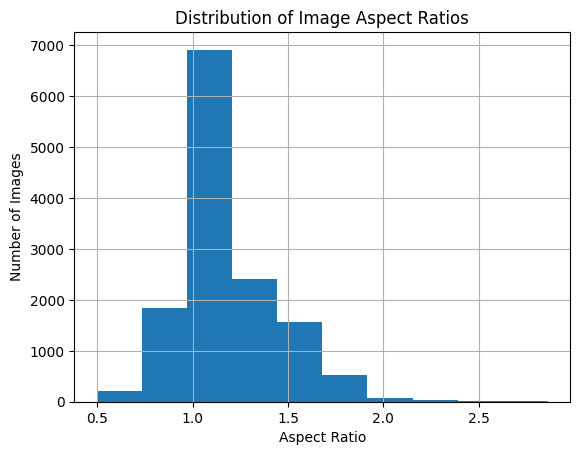

In [37]:
ax = df["aspect_ratio"].hist()

ax.set_xlabel("Aspect Ratio")
ax.set_ylabel("Number of Images")
ax.set_title("Distribution of Image Aspect Ratios")